In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import Sampler
import matplotlib.pyplot 
import numpy as np

In [ ]:
# circuit parameters
Q = 2
q0 = 0
q1 = 1

C = 2
c0 = 0
c1 = 1

# angle parameters
a0 = 0
a1 = np.pi/2
b0 = - np.pi/4
b1 = np.pi/4


Let's create four circuits for such control-target combinations:

* 00
* 11
* 01
* 10

In [ ]:
qc_bell_00 = QuantumCircuit(Q) 
qc_bell_00.h(q0)
qc_bell_00.cx(q0,q1)
qc_bell_00.rz(a0,q0)
qc_bell_00.rz(b0,q1)
qc_bell_00.h(q0)
qc_bell_00.h(q1)
qc_bell_00.measure_all()

In [40]:
qc_bell_01 = QuantumCircuit(Q) 
qc_bell_01.h(q0)
qc_bell_01.cx(q0,q1)
qc_bell_01.rz(a0,q0)
qc_bell_01.rz(b1,q1)
qc_bell_01.h(q0)
qc_bell_01.h(q1)
qc_bell_01.measure_all()

In [41]:
qc_bell_10 = QuantumCircuit(Q) 
qc_bell_10.h(q0)
qc_bell_10.cx(q0,q1)
qc_bell_10.rz(a1,q0)
qc_bell_10.rz(b0,q1)
qc_bell_10.h(q0)
qc_bell_10.h(q1)
qc_bell_10.measure_all()

In [42]:
qc_bell_11 = QuantumCircuit(Q) 
qc_bell_11.h(q0)
qc_bell_11.cx(q0,q1)
qc_bell_11.rz(a1,q0)
qc_bell_11.rz(b1,q1)
qc_bell_11.h(q0)
qc_bell_11.h(q1)
qc_bell_11.measure_all()

In [31]:
def run_and_plot(circuit, circuit_name, backend = AerSimulator(), N = 1000):

    sampler = Sampler(backend)
    job=sampler.run([circuit], shots=N)
    result =job.result()

    for i in range(len(result)):
        counts = result[i].data.meas.get_counts()
        print(f"Wyniki dla obwodu {circuit_name}: {counts}")
    
    fig = circuit.draw("mpl")
    
    return counts, fig

Wyniki dla obwodu 00: {'00': 425, '11': 425, '10': 74, '01': 76}


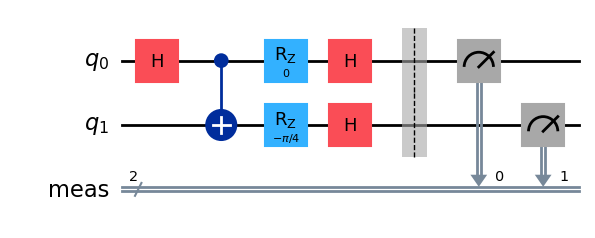

In [32]:
counts_00, fig_00 = run_and_plot(qc_bell_00, '00')
fig_00

Wyniki dla obwodu 01: {'00': 413, '11': 456, '10': 61, '01': 70}


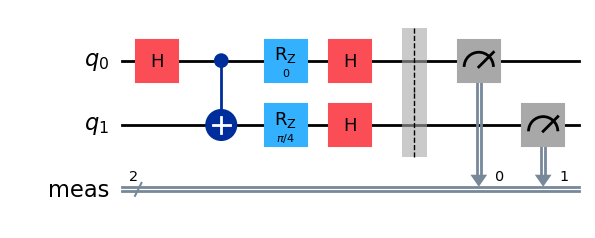

In [43]:
counts_01, fig_01 = run_and_plot(qc_bell_01, '01')
fig_01

Wyniki dla obwodu 10: {'00': 404, '11': 433, '10': 81, '01': 82}


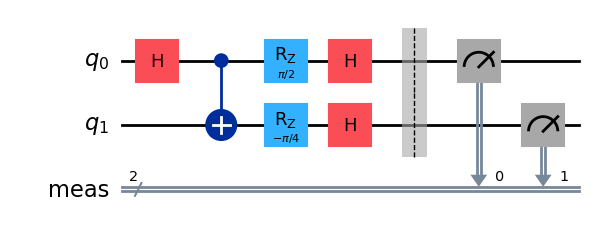

In [46]:
counts_10, fig_10 = run_and_plot(qc_bell_10, '10')
fig_10

Wyniki dla obwodu 11: {'01': 453, '10': 406, '00': 69, '11': 72}


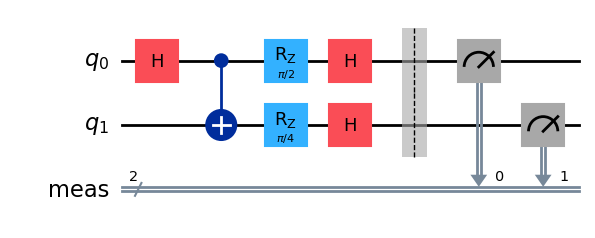

In [47]:
counts_11, fig_11 = run_and_plot(qc_bell_11, '11')
fig_11

In [52]:
def calculate_correlation(counts):

    n00 = counts.get('00', 0)
    n11 = counts.get('11', 0)
    n01 = counts.get('01', 0)
    n10 = counts.get('10', 0)
    
    total = n00 + n11 + n01 + n10

    return (n00 - n10 - n01 + n11) / total


E00 = calculate_correlation(counts_00)
E01 = calculate_correlation(counts_01)
E10 = calculate_correlation(counts_10)
E11 = calculate_correlation(counts_11)


S = E00 + E01 + E10 - E11

print(f"Korelacje: E00={E00:.3f}, E01={E01:.3f}, E10={E10:.3f}, E11={E11:.3f}")
print(f"Wartość S = {abs(S):.4f}")

if abs(S) > 2:
    print("Nierówność Bella została NARUSZONA (kwantowo)")
else:
    print("Nierówność Bella NIE została naruszona (klasycznie)")

Korelacje: E00=0.700, E01=0.738, E10=0.674, E11=-0.718
Wartość S = 2.8300
Nierówność Bella została NARUSZONA (kwantowo)
